# Particle Filter Wall-Clock Test:

## 1. Supporting Functions:

The `GalieleoEvents` repository calls several scripts. The main driver script to run the generative model is `/tests/mc_gm.jl`. This script includes the file `/src/GalileoEvents.jl` which calls `/src/utils/utils.jl` and `/src/gms/gms.jl`. The utils script calls the `distributions.jl` file which defines probability distributions used later on. It also includes `scene.jl` which creates the ramp. The gms script includes the generative model for the particle filter and the changepoint-model. The normal particle filter code exists in the `/src/gms/mc_gm.jl` file. I suspect that `/src/analysis.jl` has the inference code (need to check through it). 

*I will re-implement all of the required functions within this notebook. We can re-distribute the code as functions later on, but it would be useful to have one source that can run every part properly.*

### 1.1 Import Functions

These packages were added to the relevant conda and julia environments and pre-compiled. This allows quick loading in the jupyter environment. 

In [1]:
using Accessors
using Gen
using Compose
using PhySMC
using PhyBullet
using PyCall
using Parameters
using DocStringExtensions
using Distributions
using LinearAlgebra
using Random
using Statistics
using Plots

pybullet build time: Oct 21 2025 11:20:22


### 1.2 Create a Scene:

This uses the code from `/src/utils/scene.jl`. We create a ramp object and the objects on it. The `ramp()` function achieves this, and has the following function signature:

`ramp(mass_ratio::Float64, obj_frictions::NTuple{2, Float64}, obj_positions::NTuple{2}; slope, ramp_intersection)`

In [2]:
function ramp(mass_ratio::Float64, obj_frictions::NTuple{2, Float64} = (.5, .5), obj_positions::NTuple{2, Float64} = (0.5, 1.5), slope::Float64=2/3, tableRampIntersection::Float64=0.0)
    
    # for debugging
    #client = @pycall pb.connect(pb.GUI)::Int64
    #pb.resetDebugVisualizerCamera(4.5, 0, -40, [0.0, 0.0, 0.0]; physicsClientId=client)

    # Set up the pybullet client and set gravity at -10
    client = @pycall pb.connect(pb.DIRECT)::Int64
    pb.setGravity(0,0,-10; physicsClientId = client)


    # add a table base (setting mass = 0 makes it a static object)
    grey = [0.5, 0.5, 0.5, 1]
    base_dims = [5, 1, 0.75] # in meters
    table_dims = [base_dims[1] + 0.2, base_dims[2] + 0.2, 0.1]  # Width, depth, height
    table_base_col_id = pb.createCollisionShape(pb.GEOM_BOX, halfExtents = base_dims / 2, physicsClientId = client)
    table_base_obj_id = pb.createMultiBody(baseCollisionShapeIndex = table_base_col_id, basePosition = [0,0,-(base_dims[3]+table_dims[3])/2], physicsClientId = client)
    pb.changeDynamics(table_base_obj_id, -1; mass = 0., restitution = 0.9, physicsClientId=client)
    pb.changeVisualShape(table_base_obj_id, -1, rgbaColor=grey, physicsClientId=client)

    # Create the tabletop (a flat box)
    table_col_id = pb.createCollisionShape(pb.GEOM_BOX, halfExtents=table_dims/2)
    table_body_id = pb.createMultiBody(baseCollisionShapeIndex=table_col_id, basePosition=[0, 0, -table_dims[3]/2])
    pb.changeDynamics(table_body_id, -1; mass = 0., restitution = 0.9, physicsClientId=client)
    pb.changeVisualShape(table_body_id, -1, rgbaColor=grey.+0.2, physicsClientId=client)

    # Create the four frame-like boxes around the tabletop
    frame_height = 0.25
    frame_thickness = 0.05

    frame_dims = [
        [table_dims[1] + 2 * frame_thickness, frame_thickness, frame_height],  # Longer sides
        [table_dims[1] + 2 * frame_thickness, frame_thickness, frame_height],  # Longer sides
        [frame_thickness, table_dims[2], frame_height],  # Shorter sides
        [frame_thickness, table_dims[2], frame_height]  # Shorter sides
    ]

    frame_positions = [
        [0, table_dims[2] / 2 + frame_thickness / 2, 0],  # Top side
        [0, -table_dims[2] / 2 - frame_thickness / 2, 0],  # Bottom side
        [table_dims[1] / 2 + frame_thickness / 2, 0, 0],  # Right side
        [-table_dims[1] / 2 - frame_thickness / 2, 0, 0]  # Left side
    ]

    for (dims, pos) in zip(frame_dims, frame_positions)
        frame_col_id = pb.createCollisionShape(pb.GEOM_BOX, halfExtents=dims/2)::Int64
        frame_obj_id = pb.createMultiBody(baseCollisionShapeIndex=frame_col_id, basePosition=pos)::Int64
        pb.changeVisualShape(frame_obj_id, -1, rgbaColor=grey, physicsClientId=client)
    end

    # add a ramp
    pb.setAdditionalSearchPath("/gpfs/radev/project/yildirim/aa2842/minimum-simulation-capsules")
    ramp_col_id = pb.createCollisionShape(pb.GEOM_MESH, fileName="/assets/ramp.obj", physicsClientId=client, meshScale=[2, base_dims[2], slope*2])
    ramp_position = [-2+tableRampIntersection, -base_dims[2]/2, 0]
    ramp_obj_id = pb.createMultiBody(baseCollisionShapeIndex=ramp_col_id, basePosition=ramp_position, physicsClientId=client)
    pb.changeDynamics(ramp_obj_id, -1; mass=0.0, restitution=0.9, physicsClientId=client)
    pb.changeVisualShape(ramp_obj_id, -1, rgbaColor=[1, 1, 1, 1], physicsClientId=client)

    # add a floor
    floor_col_id = pb.createCollisionShape(pb.GEOM_PLANE, physicsClientId=client)
    floor_obj_id = pb.createMultiBody(baseCollisionShapeIndex=floor_col_id, basePosition=[0,0,-base_dims[3]], physicsClientId=client)
    pb.changeDynamics(floor_obj_id, -1; mass=0.0, restitution=0.9, physicsClientId=client)


    #  add walls
    wall_dims = [[0.1, 8.0, 5.0], [0.1, 8.0, 5.0], [8.0, 0.1, 5.0]] # Width, length, height
    wall_positions = [
        [4.0, 0.0, 1.0],  # Right Wall
        [-4.0, 0.0, 1.0],  # Left Wall
        [0, 4, wall_dims[3][3]/2-base_dims[3]] # Back Wall
    ]
    for (dims, pos) in zip(wall_dims, wall_positions)
        wall_col_id = pb.createCollisionShape(pb.GEOM_BOX, halfExtents=dims./2, physicsClientId=client)
        wall_obj_id = pb.createMultiBody(baseCollisionShapeIndex=wall_col_id, basePosition=pos, physicsClientId=client)
        pb.changeDynamics(wall_obj_id, -1; mass=0.0, restitution=0.9, physicsClientId=client)
        pb.changeVisualShape(wall_obj_id, -1, rgbaColor=grey+[0.2, 0.2, 0.2, 0], physicsClientId=client)
    end

    # add an object on the ramp
    obj_ramp_dims = [0.15, 0.3, 0.075]
    theta_radians = -atan(slope)
    orientation = [cos(theta_radians / 2), 0, sin(theta_radians / 2), 0]

    obj_on_ramp_col_id = pb.createCollisionShape(pb.GEOM_BOX, halfExtents=obj_ramp_dims/2, physicsClientId=client)
    lift = obj_ramp_dims[3]/2
    position = [
        -2+2*obj_positions[1]+tableRampIntersection+lift*cos(theta_radians),
        0,
        (2-2*obj_positions[1])*slope-lift*sin(theta_radians)
    ]
    obj_on_ramp_obj_id = pb.createMultiBody(baseCollisionShapeIndex=obj_on_ramp_col_id, basePosition=position, baseOrientation=orientation, physicsClientId=client)
    pb.changeDynamics(obj_on_ramp_obj_id, -1; mass=mass_ratio, restitution=0.9, lateralFriction=obj_frictions[1], physicsClientId=client)
    
    # add an object on the table that will collide with the object on the ramp as that one slides down
    obj_on_table_dims = [0.2, 0.2, 0.1]
    obj_on_table_col_id = pb.createCollisionShape(pb.GEOM_BOX, halfExtents=obj_on_table_dims/2, physicsClientId=client)
    obj_on_table_obj_id = pb.createMultiBody(baseCollisionShapeIndex=obj_on_table_col_id, basePosition=[2.5*(obj_positions[2]-1), 0, obj_on_table_dims[3]/2], physicsClientId=client)
    pb.changeDynamics(obj_on_table_obj_id, -1; mass=1.0, restitution=0.9, lateralFriction=obj_frictions[2], physicsClientId=client)

    (client, obj_on_ramp_obj_id, obj_on_table_obj_id)
end

ramp (generic function with 5 methods)

### 1.3 All Code for Drift

In [3]:
################################################################################
# Observation model
################################################################################

@gen function observe(state::RigidBodyState)
    position ~ broadcasted_normal(state.position, 0.05)
    return position
end

################################################################################
# Latent update helpers
################################################################################

function update_latents(ls::RigidBodyLatents, mass::Float64)
    RigidBodyLatents(setproperties(ls.data; mass=mass))
end

################################################################################
# Initial prior 
################################################################################

@gen function sample_object(ls::RigidBodyLatents)
    mass ~ gamma(1.2, 10.0)
    return update_latents(ls, mass)
end

@gen function prior(old_latents::Vector{BulletElemLatents})
    obj1 ~ sample_object(old_latents[1])
    obj2 = update_latents(old_latents[2], 1.0)
    return BulletElemLatents[obj1, obj2]
end

################################################################################
# Truncated normal 
################################################################################

struct TruncNorm <: Gen.Distribution{Float64} end
const trunc_norm = TruncNorm()

function Gen.random(::TruncNorm, mu::U, noise::T, low::T, high::T) where {U<:Real,T<:Real}
    d = Distributions.Truncated(Distributions.Normal(mu, noise), low, high)
    return Distributions.rand(d)
end

function Gen.logpdf(::TruncNorm, x::Float64, mu::U, noise::T, low::T, high::T) where {U<:Real,T<:Real}
    d = Distributions.Truncated(Distributions.Normal(mu, noise), low, high)
    return Distributions.logpdf(d, x)
end

################################################################################
# Drift model 
################################################################################

"""
Drift the unknown object's mass around its previous value.
"""
@gen function drift_object(ls::RigidBodyLatents, drift_std::Float64)
    prev_mass = ls.data.mass
    mass ~ trunc_norm(prev_mass, drift_std, 0.0, Inf) #TODO give an upper bound
    return update_latents(ls, mass)
end

"""
Apply latent drift before the next physics step.
Only obj1 drifts; obj2 is kept fixed at mass=1.
"""
@gen function drift_step(prev::BulletState, drift_std::Float64)
    obj1 ~ drift_object(prev.latents[1], drift_std)
    obj2 = update_latents(prev.latents[2], 1.0)
    new_latents = BulletElemLatents[obj1, obj2]
    new_state = Accessors.setproperties(prev; latents=new_latents)
    return new_state
end

"""
Drift latents, then run deterministic physics, then get noisy observations.
"""
@gen (static) function drift_physics_step(t::Int, prev::BulletState, sim::BulletSim, drift_std::Float64)
    drift ~ drift_step(prev, drift_std)
    next_state::BulletState = PhySMC.step(sim, drift)
    positions ~ drift_positions(next_state.kinematics)
    return next_state
end

drift_positions = Gen.Map(observe)

@gen (static) function drift_model(T::Int, sim::BulletSim, template::BulletState, drift_std::Float64)
    latents ~ prior(template.latents)
    init_state = Accessors.setproperties(template; latents=latents)
    states ~ drift_chain(T, init_state, sim, drift_std)
    return states
end

drift_chain = Gen.Unfold(drift_physics_step)
Gen.@load_generated_functions

################################################################################
# Observation construction
################################################################################

function make_observations(observed_positions)
    T = length(observed_positions)
    obs = Vector{Gen.ChoiceMap}(undef, T)

    for t in 1:T
        cm = Gen.choicemap()
        cm[:states => t => :positions => 1 => :position] = observed_positions[t][1]
        cm[:states => t => :positions => 2 => :position] = observed_positions[t][2]
        obs[t] = cm
    end

    return obs
end


function observations_from_trace(tr::Gen.Trace)
    choices = get_choices(tr)
    T = get_args(tr)[1]
    out = Vector{Any}(undef, T)

    for t in 1:T
        p1 = choices[:states => t => :positions => 1 => :position]
        p2 = choices[:states => t => :positions => 2 => :position]
        out[t] = [p1, p2]
    end

    return out
end

################################################################################
# Rejuvenation proposal for drift model
################################################################################

"""
MH proposal for the drifted mass at a specific time t.
Address path is:
:states => t => :drift => :obj1 => :mass
"""
@gen function drift_proposal(tr::Gen.Trace, t::Int)
    choices = get_choices(tr)
    prev_mass = choices[:states => t => :drift => :obj1 => :mass]
    mass = {:states => t => :drift => :obj1 => :mass} ~ trunc_norm(prev_mass, 0.25, 0.0, Inf) # TODO upper bound (same as above)
    return mass
end

function drift_inference_procedure(gm_args::Tuple,
                                   obs::Vector{Gen.ChoiceMap},
                                   particles::Int=20,
                                   rejuv_moves::Int=1)

    # gm_args = (T, sim, template, drift_std)
    get_args(t) = (t, gm_args[2:4]...)

    state = Gen.initialize_particle_filter(drift_model, get_args(0), EmptyChoiceMap(), particles)
    argdiffs = (UnknownChange(), NoChange(), NoChange(), NoChange())

    for (t, o) in enumerate(obs)
        Gen.particle_filter_step!(state, get_args(t), argdiffs, o)
        Gen.maybe_resample!(state, ess_threshold=particles / 2)

        for i in 1:particles, s in 1:rejuv_moves
            # state.traces[i], _ = Gen.mh(state.traces[i], drift_proposal, (t,)) # use selection instead of a proposal function; 
            state.traces[i], _ = Gen.mh(state.traces[i], Gen.select(:states => t => :drift => :obj1 => :mass)) # use selection instead of a proposal function;
        end
    end

    return Gen.sample_unweighted_traces(state, particles)
end

################################################################################
# Posterior summaries over time
################################################################################

function extract_current_drift_mass(tr::Gen.Trace, t::Int)
    get_choices(tr)[:states => t => :drift => :obj1 => :mass]
end

function summarize_drift_masses(traces, t::Int)
    ms = [extract_current_drift_mass(tr, t) for tr in traces]
    return (
        mean = mean(ms),
        std = std(ms),
        q05 = quantile(ms, 0.05),
        q25 = quantile(ms, 0.25),
        q75 = quantile(ms, 0.75),
        q95 = quantile(ms, 0.95),
        masses = ms
    )
end

function drift_inference_with_history(gm_args::Tuple,
                                      obs::Vector{Gen.ChoiceMap},
                                      particles::Int=20,
                                      rejuv_moves::Int=1)

    get_args(t) = (t, gm_args[2:4]...)

    state = Gen.initialize_particle_filter(drift_model, get_args(0), EmptyChoiceMap(), particles)
    argdiffs = (UnknownChange(), NoChange(), NoChange(), NoChange())

    history = Vector{NamedTuple}(undef, length(obs))

    for (t, o) in enumerate(obs)
        Gen.particle_filter_step!(state, get_args(t), argdiffs, o)
        Gen.maybe_resample!(state, ess_threshold=particles / 2)

        for i in 1:particles, s in 1:rejuv_moves
            state.traces[i], _ = Gen.mh(state.traces[i], drift_proposal, (t,))
        end

        current_traces = Gen.sample_unweighted_traces(state, particles)
        summ = summarize_drift_masses(current_traces, t)

        history[t] = (
            t = t,
            mean = summ.mean,
            std = summ.std,
            q05 = summ.q05,
            q25 = summ.q25,
            q75 = summ.q75,
            q95 = summ.q95,
            traces = current_traces
        )
    end

    return history
end

################################################################################
# Collision detection and plotting
################################################################################

function detect_collision_time(observed_positions; threshold=0.25)
    T = length(observed_positions)
    for t in 1:T
        p1 = observed_positions[t][1]
        p2 = observed_positions[t][2]
        d = sqrt(sum((p1 .- p2).^2))
        if d < threshold
            return t
        end
    end
    return nothing
end

function plot_mass_ratio_history(history; collision_time=nothing, use_quantiles=true)
    ts = [h.t for h in history]
    means = [h.mean for h in history]

    if use_quantiles
        lower = [h.q05 for h in history]
        upper = [h.q95 for h in history]
        yerr = (means .- lower, upper .- means)
    else
        stds = [h.std for h in history]
        yerr = stds
    end

    p = plot(
        ts, means;
        yerror=yerr,
        xlabel="time",
        ylabel="mass ratio",
        label="posterior mean",
        lw=2,
        marker=:circle
    )

    if collision_time !== nothing
        vline!(p, [collision_time], label="collision time", lw=2, ls=:dash)
    end

    return p
end

################################################################################
# Synthetic smoke test for drift model
################################################################################

function run_drift_smoke_test(T::Int, sim, template, drift_std::Float64; particles=30, rejuv_moves=2)
    true_trace, = Gen.generate(drift_model, (T, sim, template, drift_std))
    observed_positions = observations_from_trace(true_trace)
    obs = make_observations(observed_positions)

    history = drift_inference_with_history((T, sim, template, drift_std), obs, particles, rejuv_moves)
    collision_time = detect_collision_time(observed_positions)

    return (
        true_trace = true_trace,
        observed_positions = observed_positions,
        obs = obs,
        history = history,
        collision_time = collision_time
    )
end

run_drift_smoke_test (generic function with 1 method)

In [27]:
mass_ratio = 2.0
obj_frictions = (0.3, 0.3)
obj_positions = (0.5, 1.5)

client, obj_1, obj_2 = ramp(mass_ratio, obj_frictions, obj_positions)

# create PhySMC and PhyBullet objects
sim = BulletSim(; client=client)
obj_r = RigidBody(obj_1)           # ramp obj
obj_t = RigidBody(obj_2)           # table obj

# get an initial state (to be overwritten in the prior function)
init_state = BulletState(sim, [obj_r, obj_t]);

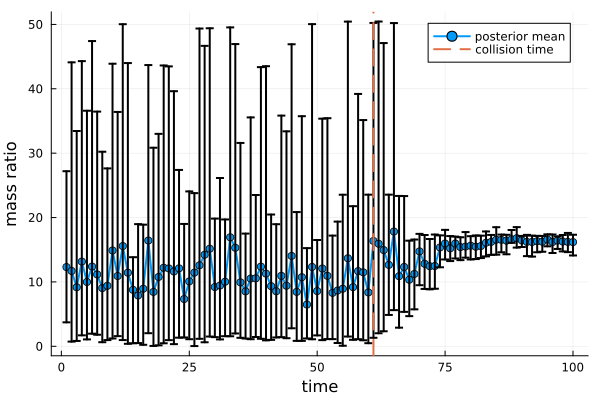

In [29]:
T = 100
drift_std = 0.15

res = run_drift_smoke_test(T, sim, init_state, drift_std; particles=30, rejuv_moves=2)

p = plot_mass_ratio_history(res.history; collision_time=res.collision_time, use_quantiles=true)
display(p)

In [4]:

"""
Choose Gamma(shape, scale) parameters from a target mean and standard deviation.
"""
function gamma_from_mean_std(mean_mass::Real, std_mass::Real)
    μ = Float64(mean_mass)
    σ = Float64(std_mass)
    μ > 0 || error("mean_mass must be positive")
    σ > 0 || error("std_mass must be positive")

    shape = (μ / σ)^2
    scale = (σ^2) / μ
    return (shape=shape, scale=scale)
end

"""
Create a generic timing spec for a sequential particle filter.

Required keyword arguments:
- label: name shown in the plot legend
- pf_model: the Gen model used by the particle filter
- gm_args_builder: builds the full model args from (T, sim, template)
- online_args: converts full model args into the per-step args function get_args(t)
- argdiffs: the argdiff tuple for particle_filter_step!
- rejuvenate!: function(state, t, particles, rejuv_moves)
"""
function make_pf_timing_spec(; label,
                                pf_model,
                                gm_args_builder,
                                online_args,
                                argdiffs,
                                rejuvenate!)
    return (
        label = label,
        pf_model = pf_model,
        gm_args_builder = gm_args_builder,
        online_args = online_args,
        argdiffs = argdiffs,
        rejuvenate! = rejuvenate!
    )
end

"""
Convenience constructor for the static particle-filter model in this notebook.
"""
function standard_pf_timing_spec(; label="particle filter", proposal_fn=proposal)
    return make_pf_timing_spec(
        label = label,
        pf_model = model,
        gm_args_builder = (T, sim, template) -> (T, sim, template),
        online_args = gm_args -> (t -> (t, gm_args[2:3]...)),
        argdiffs = (UnknownChange(), NoChange(), NoChange()),
        rejuvenate! = function (state, t, particles, rejuv_moves)
            for i in 1:particles, s in 1:rejuv_moves
                state.traces[i], _ = Gen.mh(state.traces[i], proposal_fn, ())
            end
            return nothing
        end
    )
end

"""
Sample one shared bank of observation sequences.

The RNG is seeded inside this function so repeated calls with the same inputs
produce the same scenes. That gives a fair runtime comparison across models.
"""
function sample_shared_scene_bank(T::Int, sim, template;
                                  n_scenes::Int=10,
                                  scene_model=model,
                                  scene_args_builder=(T, sim, template) -> (T, sim, template),
                                  seed::Int=1)
    Random.seed!(seed)
    scenes = Vector{NamedTuple}(undef, n_scenes)
    scene_args = scene_args_builder(T, sim, template)

    for scene_idx in 1:n_scenes
        true_trace, = Gen.generate(scene_model, scene_args)
        observed_positions = observations_from_trace(true_trace)
        obs = make_observations(observed_positions)

        scenes[scene_idx] = (
            scene_idx = scene_idx,
            true_trace = true_trace,
            observed_positions = observed_positions,
            obs = obs,
            collision_time = detect_collision_time(observed_positions)
        )
    end

    return scenes
end

function _run_timed_filter_pass(spec,
                                gm_args,
                                obs::Vector{Gen.ChoiceMap};
                                particles::Int=20,
                                rejuv_moves::Int=1,
                                measure::Bool=true)
    get_args = spec.online_args(gm_args)
    state = Gen.initialize_particle_filter(spec.pf_model, get_args(0), EmptyChoiceMap(), particles)
    step_times_s = zeros(length(obs))

    for (t, obs_t) in enumerate(obs)
        elapsed = @elapsed begin
            Gen.particle_filter_step!(state, get_args(t), spec.argdiffs, obs_t)
            Gen.maybe_resample!(state, ess_threshold=particles / 2)
            spec.rejuvenate!(state, t, particles, rejuv_moves)
        end

        if measure
            step_times_s[t] = elapsed
        end
    end

    return step_times_s
end

"""
Benchmark per-step runtime for a single timing spec on a fixed scene bank.
"""
function benchmark_step_runtime(spec,
                                scenes,
                                T::Int,
                                sim,
                                template;
                                particles::Int=30,
                                rejuv_moves::Int=2,
                                warmup::Bool=true)
    gm_args = spec.gm_args_builder(T, sim, template)

    if warmup && !isempty(scenes)
        _run_timed_filter_pass(spec, gm_args, scenes[1].obs;
                               particles=particles,
                               rejuv_moves=rejuv_moves,
                               measure=false)
    end

    step_times_s = Matrix{Float64}(undef, length(scenes), T)
    collision_times = Vector{Union{Nothing, Int}}(undef, length(scenes))

    for (scene_idx, scene) in enumerate(scenes)
        println("Benchmarking $(spec.label), scene $scene_idx / $(length(scenes))", ", collision_time = $(scene.collision_time)")
        
        step_times_s[scene_idx, :] = _run_timed_filter_pass(spec, gm_args, scene.obs;
                                                           particles=particles,
                                                           rejuv_moves=rejuv_moves,
                                                           measure=true)
        collision_times[scene_idx] = scene.collision_time
    end

    mean_ms = 1000.0 .* vec(mean(step_times_s; dims=1))
    std_ms = 1000.0 .* vec(std(step_times_s; dims=1))
    median_ms = 1000.0 .* [median(view(step_times_s, :, t)) for t in 1:T]
    q25_ms = 1000.0 .* [quantile(view(step_times_s, :, t), 0.25) for t in 1:T]
    q75_ms = 1000.0 .* [quantile(view(step_times_s, :, t), 0.75) for t in 1:T]

    return (
        label = spec.label,
        step_times_s = step_times_s,
        mean_ms = mean_ms,
        std_ms = std_ms,
        median_ms = median_ms,
        q25_ms = q25_ms,
        q75_ms = q75_ms,
        collision_times = collision_times
    )
end

"""
Plot per-step inference time for one or more particle-filter models.

By default the line is the mean over scenes and the ribbon is +/- one std.
If summary=:median, the line is the median and the ribbon is the interquartile range.
"""
function plot_step_runtime_comparison(model_specs;
                                      T::Int,
                                      sim,
                                      template,
                                      scenes=nothing,
                                      n_scenes::Int=10,
                                      scene_model=model,
                                      scene_args_builder=(T, sim, template) -> (T, sim, template),
                                      particles::Int=30,
                                      rejuv_moves::Int=2,
                                      seed::Int=1,
                                      warmup::Bool=true,
                                      summary::Symbol=:mean)

    scene_bank = isnothing(scenes) ? sample_shared_scene_bank(T, sim, template;
                                                              n_scenes=n_scenes,
                                                              scene_model=scene_model,
                                                              scene_args_builder=scene_args_builder,
                                                              seed=seed) : scenes

    results = [benchmark_step_runtime(spec, scene_bank, T, sim, template;
                                      particles=particles,
                                      rejuv_moves=rejuv_moves,
                                      warmup=warmup) for spec in model_specs]

    ts = 1:T
    p = plot(xlabel="filter step t",
             ylabel="runtime per step (ms)",
             title="Per-step particle-filter runtime",
             legend=:topleft)

    for result in results
        if summary == :mean
            center = result.mean_ms
            ribbon = result.std_ms
        elseif summary == :median
            center = result.median_ms
            ribbon = (result.median_ms .- result.q25_ms, result.q75_ms .- result.median_ms)
        else
            error("summary must be :mean or :median")
        end

        plot!(p, ts, center;
              ribbon=ribbon,
              label=result.label,
              lw=3,
              marker=:circle,
              ms=3)
    end

    return (
        plot = p,
        scenes = scene_bank,
        results = results
    )
end

plot_step_runtime_comparison

In [5]:
drift_spec = make_pf_timing_spec(
    label = "drift model",
    pf_model = drift_model,
    gm_args_builder = (T, sim, template) -> (T, sim, template, 0.25),
    online_args = gm_args -> (t -> (t, gm_args[2:4]...)),
    argdiffs = (UnknownChange(), NoChange(), NoChange(), NoChange()),
    rejuvenate! = function (state, t, particles, rejuv_moves)
        for i in 1:particles, s in 1:rejuv_moves
            state.traces[i], _ = Gen.mh(
                state.traces[i],
                Gen.select(:states => t => :drift => :obj1 => :mass)
            )
        end
        return nothing
    end
);

In [6]:
# Declare constants and create a scene
mass_ratio = 2.0
obj_frictions = (0.3, 0.3)
obj_positions = (0.5, 1.5)

client, obj_1, obj_2 = ramp(mass_ratio, obj_frictions, obj_positions)

(0, 11, 12)

In [7]:
# create PhySMC and PhyBullet objects
sim = BulletSim(; client=client)
obj_r = RigidBody(obj_1)           # ramp obj
obj_t = RigidBody(obj_2)           # table obj

# get an initial state (to be overwritten in the prior function)
init_state = BulletState(sim, [obj_r, obj_t]);

Benchmarking drift model, scene 1 / 5, collision_time = 60
Benchmarking drift model, scene 2 / 5, collision_time = 60
Benchmarking drift model, scene 3 / 5, collision_time = 60
Benchmarking drift model, scene 4 / 5, collision_time = 64
Benchmarking drift model, scene 5 / 5, collision_time = 66


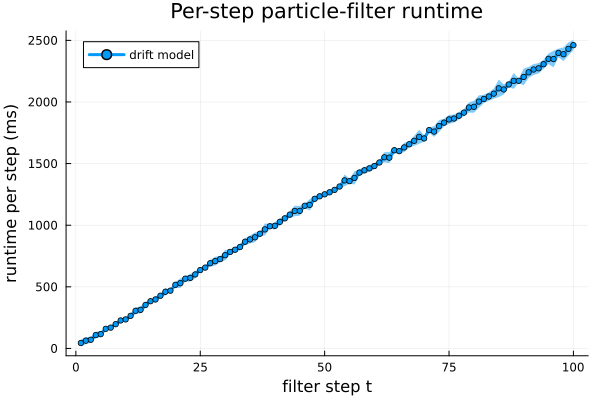

In [8]:
runtime_cmp = plot_step_runtime_comparison([drift_spec];
    T=100,
    sim=sim,
    template=init_state,
    n_scenes=5,
    scene_model=drift_model,
    scene_args_builder=(T, sim, template) -> (T, sim, template, 0.25),
    particles=30,
    rejuv_moves=2,
    seed=7)

display(runtime_cmp.plot)

In [9]:
print("hi")

hi